## [Luis Alejandro Rodríguez Arenas](https://luigitoby.github.io/)
## Cod. 202321287
# Taller 7

# Librerías

In [6]:
from sympy import symbols, Matrix, pi, cos, sin, simplify, eye, solve, latex, atan2, pprint, init_printing, Derivative, sqrt, diff, Eq, tan, integrate, lambdify
from sympy.physics.vector import dynamicsymbols, init_vprinting, ReferenceFrame, cross, Point, dot
from numpy import deg2rad, linspace, gradient
import numpy as np
import matplotlib.pyplot as plt
init_vprinting(use_latex='mathjax')
import scipy as sp
from scipy.integrate import solve_ivp

### Ej 1
Reemplace los resortes mostrados en la figura de forma que conserve la misma
frecuencia natural de vibración.
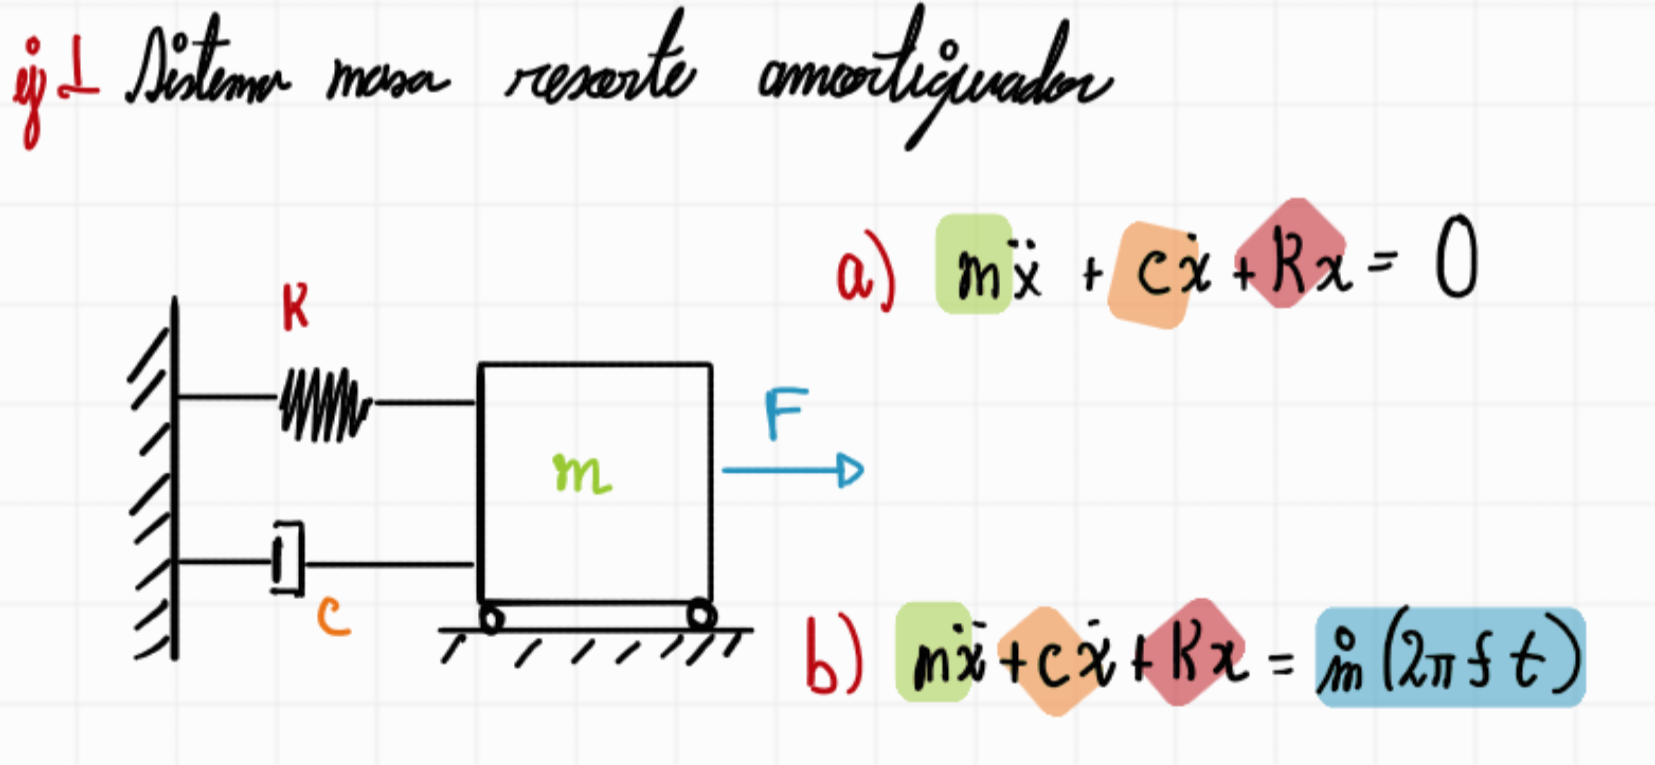
1. Considere el sistema masa,resorte que se vio en clase. Incluya un amortiguador que
produzca una fuerza proporcional a la velocidad.
A. Asigne valores de masa, constante de amortiguamiento c y constante del resorte k,
de forma que la frecuencia natural del sistema sea 5Hz. Modifique los valores para
obtener la misma frecuencia natural, pero variando los valores de 𝜁: {0,0.1,0.5,1}.
Grafique la respuesta natural del sistema en cada caso de 𝜁 bajo la misma
condición inicial diferente de 0,0.
B. Asigne valores de masa, constante de amortiguamiento c y constante del resorte k,
de forma que la frecuencia natural del sistema sea 5Hz y 𝜁: 0.5. Grafique la
respuesta natural del sistema para una entrada forzada de la forma F=sin(2π f t),
con f: {0.5,1.0,2.5,5,7.5,10}

#### Parte a

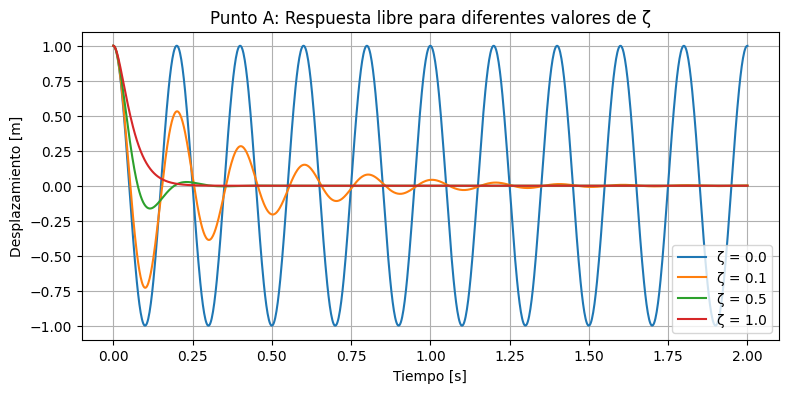

In [7]:
# ============================================================
# PUNTO A: Respuesta libre para distintos valores de zeta
# Frecuencia natural deseada: fn = 5 Hz
# ============================================================

# -----------------------------
# Descripción de variables:
# m : masa [kg]
# k : constante del resorte [N/m]
# c : coeficiente de amortiguamiento [N·s/m]
# fn : frecuencia natural en Hz
# wn : frecuencia natural en rad/s
# zeta : coeficiente de amortiguamiento
# x(t) : desplazamiento
# -----------------------------

# Definimos frecuencia natural objetivo
fn = 5.0
wn = 2 * np.pi * fn    # paso a rad/s

# Selecciono una masa cualquiera (puede ser 1 kg para simplificar)
m = 1.0

# Resorte que da la frecuencia natural que pedimos: wn = sqrt(k/m)
k = m * wn**2

# Valores de amortiguamiento que se quieren simular
zetas = [0.0, 0.1, 0.5, 1.0]

# Condiciones iniciales (deben ser no cero porque es respuesta libre)
x0 = 1.0
v0 = 0.0

# Tiempo de simulación: 2 segundos (suficiente para ver varias oscilaciones)
t_eval = np.linspace(0, 2, 1000)

# ---------------------------------------------------------
# Función que simula la respuesta libre
# ---------------------------------------------------------
def sim_respuesta_libre(m, c, k, x0, v0, t_eval):
    # Defino la ecuación diferencial 2° orden como sistema de 2 de 1° orden
    def ode(t, y):
        dx = y[1]
        dv = -(c/m)*y[1] - (k/m)*y[0]
        return [dx, dv]

    sol = solve_ivp(ode, (t_eval[0], t_eval[-1]), [x0, v0], t_eval=t_eval)
    return sol.t, sol.y[0]

# ---------------------------------------------------------
# Genero y grafico la respuesta libre para cada zeta
# ---------------------------------------------------------
plt.figure(figsize=(9,4))

for z in zetas:
    # c lo saco directo de fórmula del amortiguamiento
    c = 2 * z * m * wn

    # simulo
    t, x = sim_respuesta_libre(m, c, k, x0, v0, t_eval)

    # grafico cada una con color diferente (matplotlib los asigna automático)
    plt.plot(t, x, label=f"ζ = {z}")

plt.title("Punto A: Respuesta libre para diferentes valores de ζ")
plt.xlabel("Tiempo [s]")
plt.ylabel("Desplazamiento [m]")
plt.grid(True)
plt.legend()
plt.show()


#### Parte b

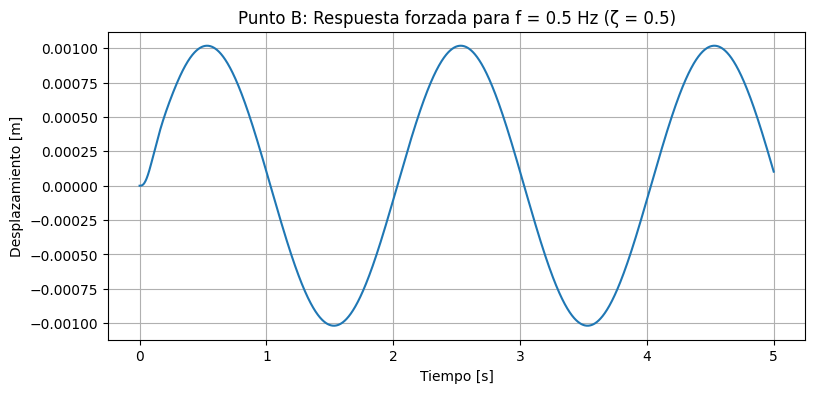

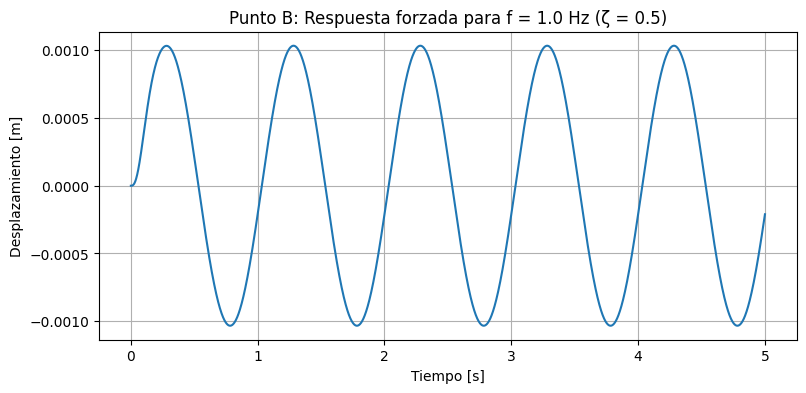

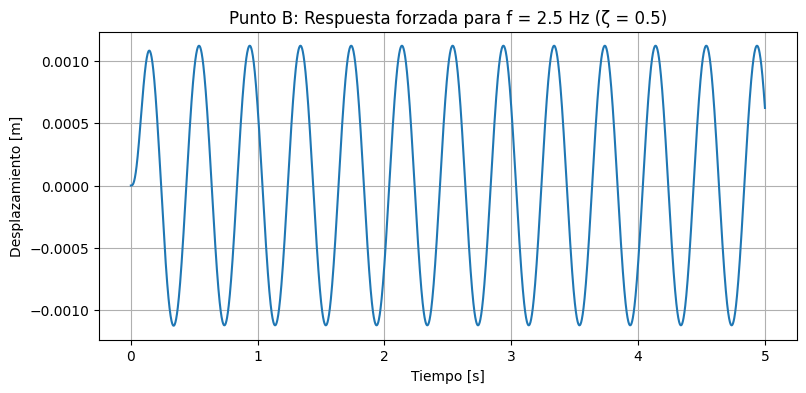

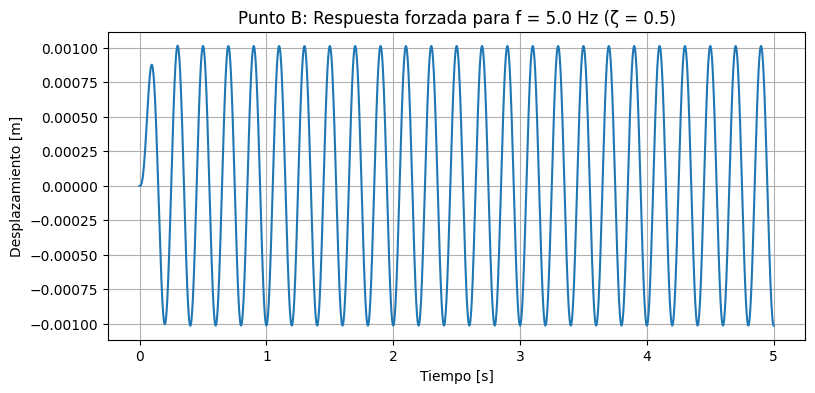

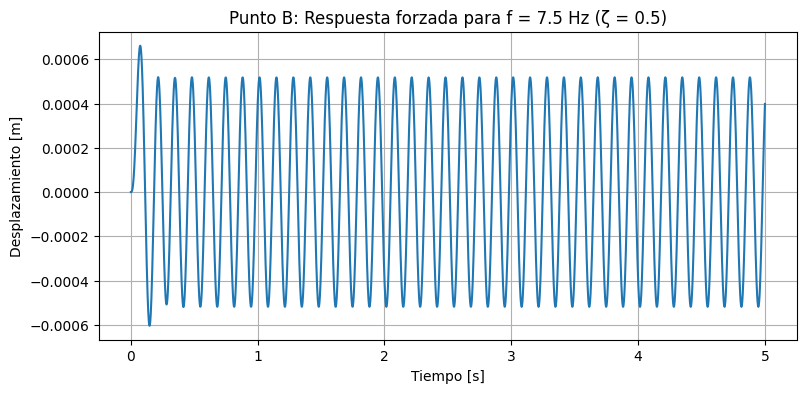

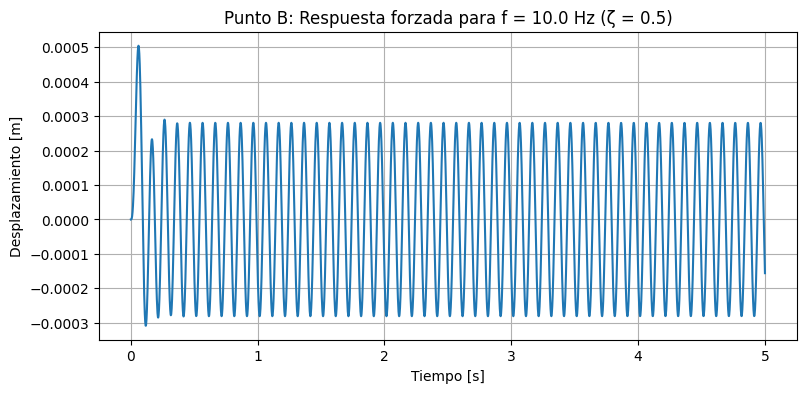

In [8]:
# ============================================================
# PUNTO B: Respuesta forzada F(t) = sin(2π f t)
# Frecuencia natural: fn = 5 Hz
# Amortiguamiento fijo: zeta = 0.5
# ============================================================

# Zeta fijo para este punto
zeta_B = 0.5
c_B = 2 * zeta_B * m * wn    # coeficiente de amortiguamiento para esta zeta

# Frecuencias de excitación que pide el enunciado
frecs = [0.5, 1.0, 2.5, 5.0, 7.5, 10.0]

# Amplitud de la fuerza (puede ser 1 sin perder generalidad)
F0 = 1.0

# Tiempo más largo para ver régimen permanente
t_eval = np.linspace(0, 5, 3000)

# ---------------------------------------------------------
# Función para simular respuesta forzada
# ---------------------------------------------------------
def sim_respuesta_forzada(m, c, k, F0, f, t_eval):
    w = 2 * np.pi * f  # frecuencia forzada en rad/s

    # Ecuación diferencial con fuerza F(t)
    def ode(t, y):
        dx = y[1]
        dv = (F0*np.sin(w*t) - c*y[1] - k*y[0]) / m
        return [dx, dv]

    sol = solve_ivp(ode, (t_eval[0], t_eval[-1]), [0,0], t_eval=t_eval)
    return sol.t, sol.y[0]

# ---------------------------------------------------------
# Graficamos una figura por cada frecuencia forzada
# ---------------------------------------------------------
for f in frecs:
    t, x = sim_respuesta_forzada(m, c_B, k, F0, f, t_eval)

    plt.figure(figsize=(9,4))
    plt.plot(t, x)  # color automático distinto
    plt.title(f"Punto B: Respuesta forzada para f = {f} Hz (ζ = 0.5)")
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Desplazamiento [m]")
    plt.grid(True)
    plt.show()


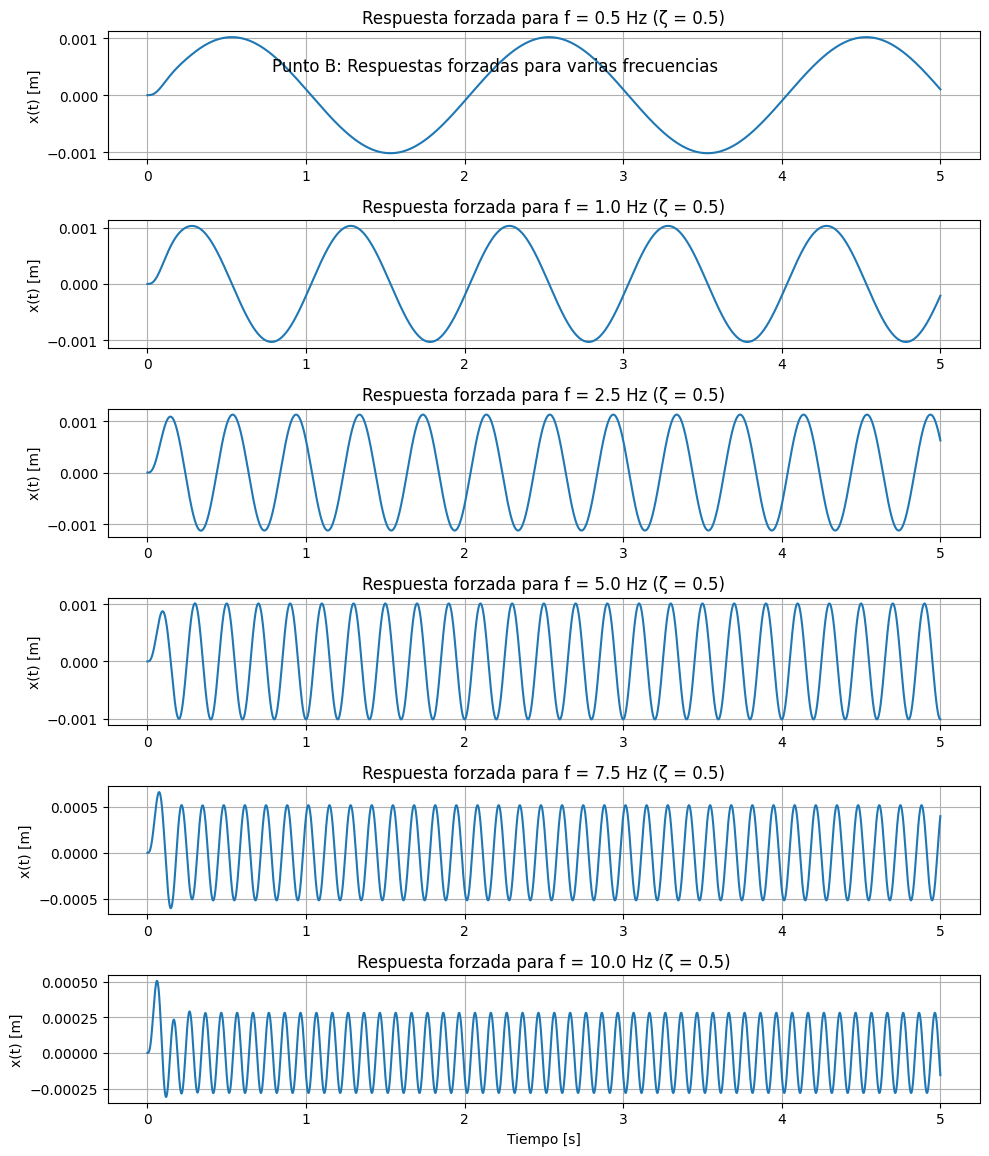

In [9]:
# Comparación de todas las respuestas forzadas en subplots

plt.figure(figsize=(10, 12))

# Número total de frecuencias
n = len(frecs)

for i, f in enumerate(frecs, start=1):
    # simulo nuevamente para cada frecuencia
    t, x = sim_respuesta_forzada(m, c_B, k, F0, f, t_eval)

    # cada frecuencia en su subplot
    plt.subplot(n, 1, i)
    plt.plot(t, x)       # color automático distinto
    plt.grid(True)

    # título individual del subplot
    plt.title(f"Respuesta forzada para f = {f} Hz (ζ = 0.5)")

    # etiquetas solo en el último para no repetir tanto
    if i == n:
        plt.xlabel("Tiempo [s]")
    plt.ylabel("x(t) [m]")

# título general
plt.suptitle("Punto B: Respuestas forzadas para varias frecuencias", y=0.92)

plt.tight_layout()
plt.show()


### Ej 2 Resortes equivalentes
Reemplace los resortes mostrados en la figura de forma que conserve la misma
frecuencia natural de vibración.
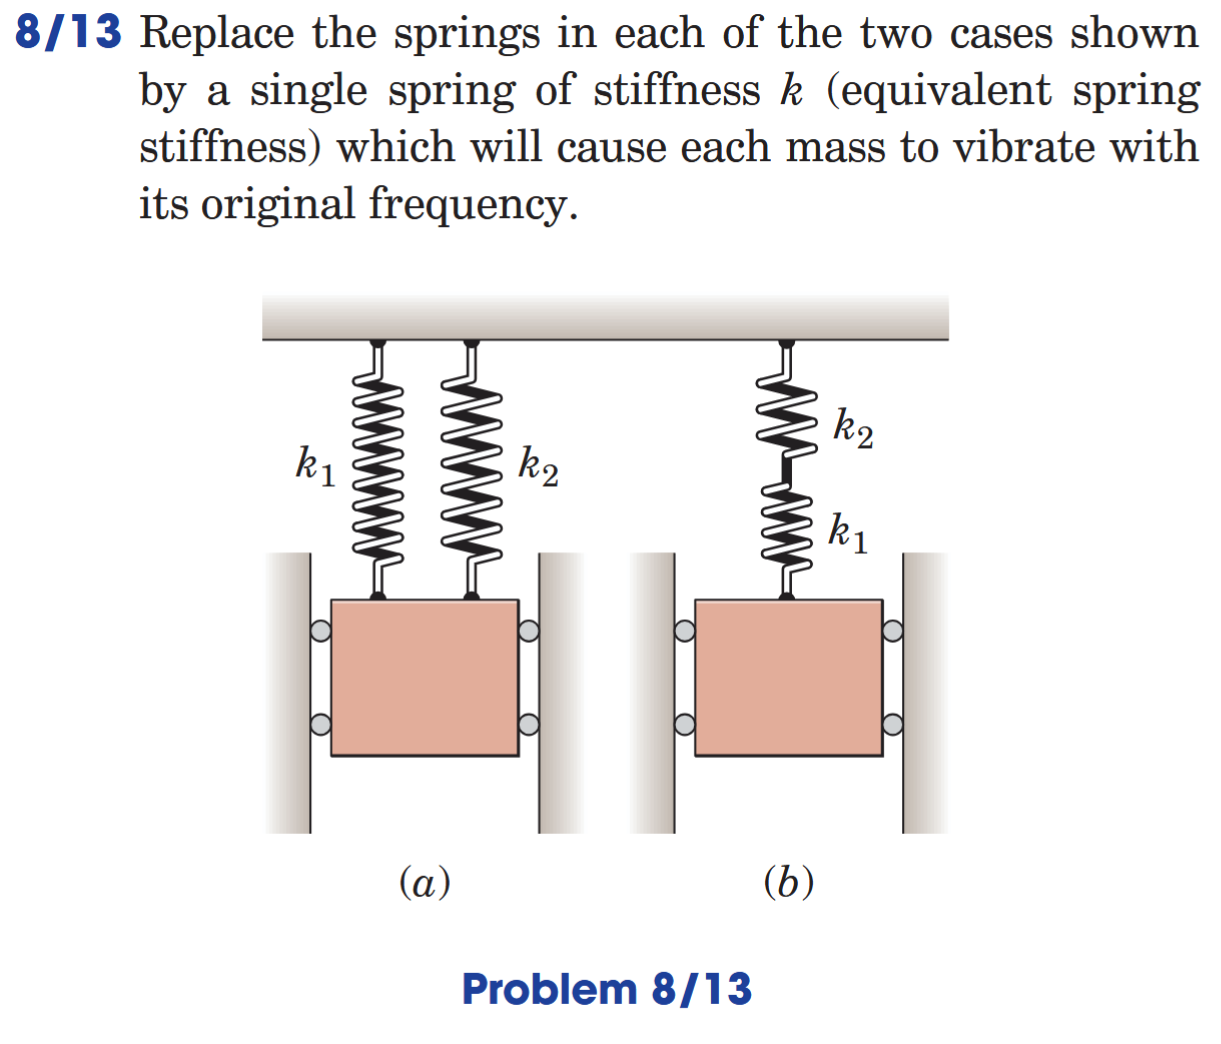
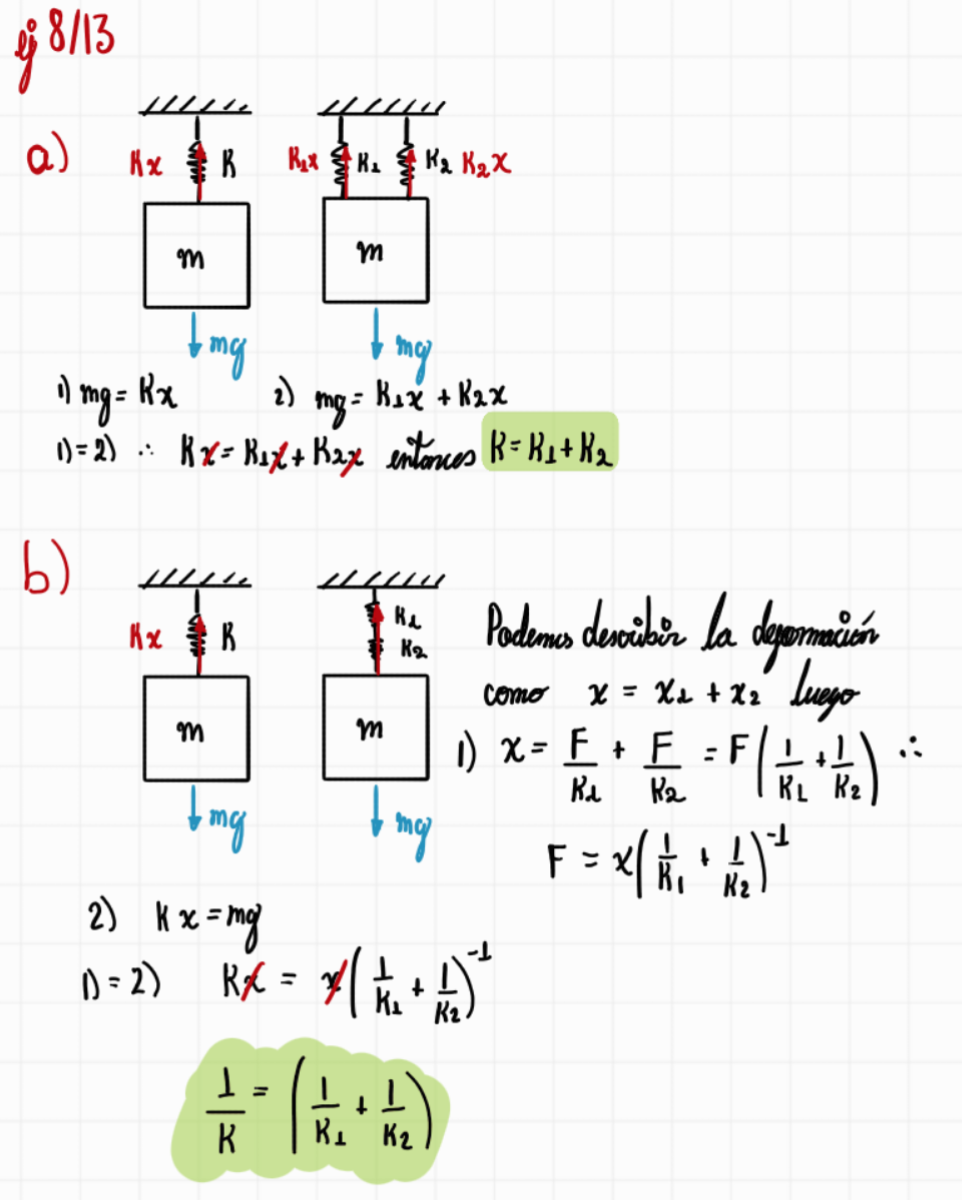

#### Ej 2 análisis
Sabemos que para mantener la misma frecuencia natural ambos sistemas tienen que cumplir con que 

$\omega_n=\sqrt{\frac{k}{m}}$, luego como las masas son iguales en ambos sistemas tenemos que asegurar que su $k_{eq}$ sea igual en ambas, ahora lo chevre es que podemos asegurar esto si tenemos en cuenta como se describe el $k$ cuando hay resortes en paralelo y en serie.

Luego para el primero estan en paralelo por lo que se tiene que:
$k_eq = k_1 + k_2$

y para el segundo estos estan en serie por lo que 

$k_{eq} = (k_1*k_2(/k_1+k_2$ (Esto es un truco robado de circuitos)

podemos computar lo así:


#### Parte a) resortes en paralelo

In [10]:
# Sabemos que para mantener la misma frecuencia natural ambos sistemas tienen que cumplir con 

# Variables simbólicas
k1, k2, m, g, K, x = symbols('k1 k2 m g K x')

Eq1 = Eq(m*g ,K*x) # Sistema equivalente
Eq3 = solve(Eq1, x) # Despejamos para x
display(Eq3)

Eq2 = Eq(m*g, k1*x + k2*x) # Sistema en paralelo

Eqf = Eq2.subs(x, Eq3[0]).simplify() # Sustituimos y despejamos para K

display(Eqf)

sol = solve(Eqf, K)[0]

display(Eq(K, sol))

⎡g⋅m⎤
⎢───⎥
⎣ K ⎦

      g⋅m⋅(k₁ + k₂)
g⋅m = ─────────────
            K      

K = k₁ + k₂

#### Parte b) resortes en serie

In [11]:
# Variables simbólicas
k1, k2, m, g, K, x = symbols('k1 k2 m g K x')

# Ecuación del sistema equivalente
Eq1 = Eq(m*g, K*x)
Eq3 = solve(Eq1, x)     # Despeje de x = mg/K
display(Eq3)

# Longitud total en serie: x = x1 + x2 = mg/k1 + mg/k2
x_series = m*g/k1 + m*g/k2

# Sustituir x en la ecuación equivalente
Eqf = Eq1.subs(x, x_series).simplify()
display(Eqf)

# Resolver para K
sol = solve(Eqf, K)[0]

display(Eq(K, sol))


⎡g⋅m⎤
⎢───⎥
⎣ K ⎦

      K⋅g⋅m⋅(k₁ + k₂)
g⋅m = ───────────────
           k₁⋅k₂     

     k₁⋅k₂ 
K = ───────
    k₁ + k₂

### Ej 3 ¡Poleas!
Calcule, en función de k, la frecuencia de oscilación vertical de la masa de 50lb mostrada en la figura. Puede ignorar la masa de las poleas.
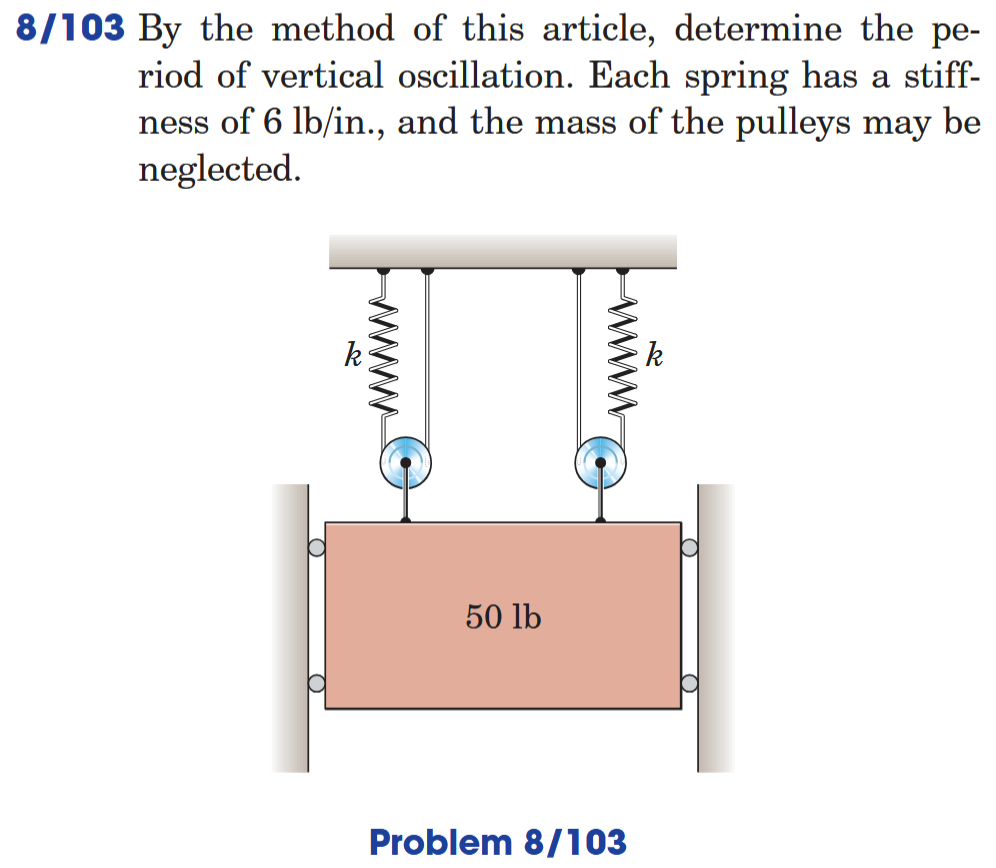
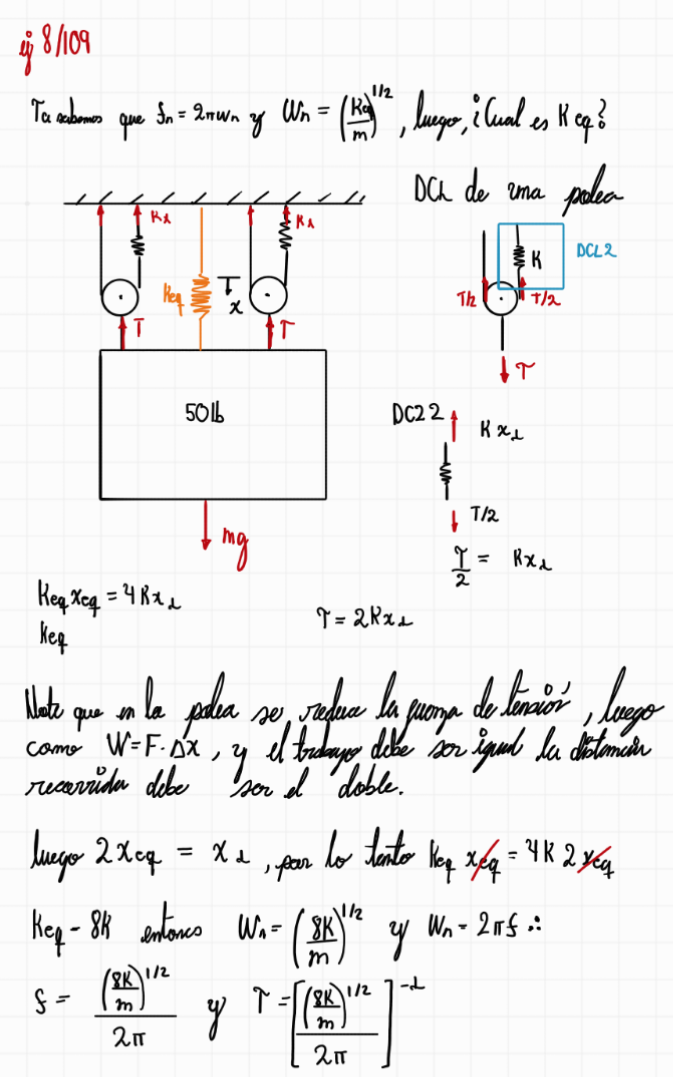

In [12]:
m, g, k_eq, x_eq, k, x, T, w_n, f_n, T_n = symbols('m g k_eq x_eq k x T w_n f_n T_n')

Eq1 = Eq(m*g ,k_eq*x_eq) # Sistema equivalente

Eq2 = Eq(m*g, 2*T) # Primer diagrama de cuerpo libre

Eq3 = Eq(T/2 , k*x) # Diagrama en la polea

Eq4 = Eq(2*x_eq , x) # Razón entre los desplazamientos

lista = [Eq1, Eq2, Eq3, Eq4] # Juntamos todo

Eqf = solve(lista, [k_eq, x, x_eq, T], dict=True) # Despejamos para cada una de las variables
display(Eqf)

display(Eqf[0][k_eq]) # Obtenemos la razón entre k_eq y k, que es de 8

display(Eq(k_eq, Eqf[0][k_eq]))

k_eq = Eqf[0][k_eq]
# thus vemos que k_eq = 8k, luego podemos armar el resto de ecuaciones relacionadas a frecuencia y periodo

⎡⎧   g⋅m                g⋅m        g⋅m⎫⎤
⎢⎨T: ───, k_eq: 8⋅k, x: ───, x_eq: ───⎬⎥
⎣⎩    2                 4⋅k        8⋅k⎭⎦

8⋅k

k_eq = 8⋅k

In [13]:
display(Eq(k_eq, k_eq))   # -> 8k

# Sustituir k_eq = 8k en fórmulas

w_expr = sqrt(k_eq/m)
w_expr = w_expr.subs(k_eq, k_eq)

f_expr = w_expr / (2*pi)
T_expr = 1 / f_expr

# Despejamos en las fórmulas

display(Eq(w_n, w_expr))
display(Eq(f_n, f_expr))
display(Eq(T_n, T_expr))

True

              ___
             ╱ k 
wₙ = 2⋅√2⋅  ╱  ─ 
          ╲╱   m 

            ___
           ╱ k 
     √2⋅  ╱  ─ 
        ╲╱   m 
fₙ = ──────────
         π     

       √2⋅π   
Tₙ = ─────────
           ___
          ╱ k 
     2⋅  ╱  ─ 
       ╲╱   m 

#### Podemos remplazar con los valores para verificar con la respuesta del libro



In [14]:
subs = {k: 6*12, m: 50/32.2}  # lbm to slugs < No me gustan las unidades inglesas

w_n_vals = w_expr.subs(subs).simplify().evalf()

f_n_vals = f_expr.subs(subs).simplify().evalf()

display(Eq(w_n, w_n_vals))
display(Eq(f_n, f_n_vals))
display(Eq(T_n, 1/f_n_vals))

wₙ = 19.2599065418293

fₙ = 3.06530932962007

Tₙ = 0.326231349748949

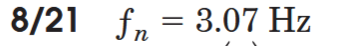
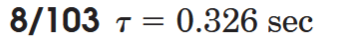

### Ej 4 El regreso de las poleas
Encuentre la constante de amortiguamiento 𝜁 equivalente para este sistema mecánico
en términos de sus parámetros (k,c,m1,m2,theta)

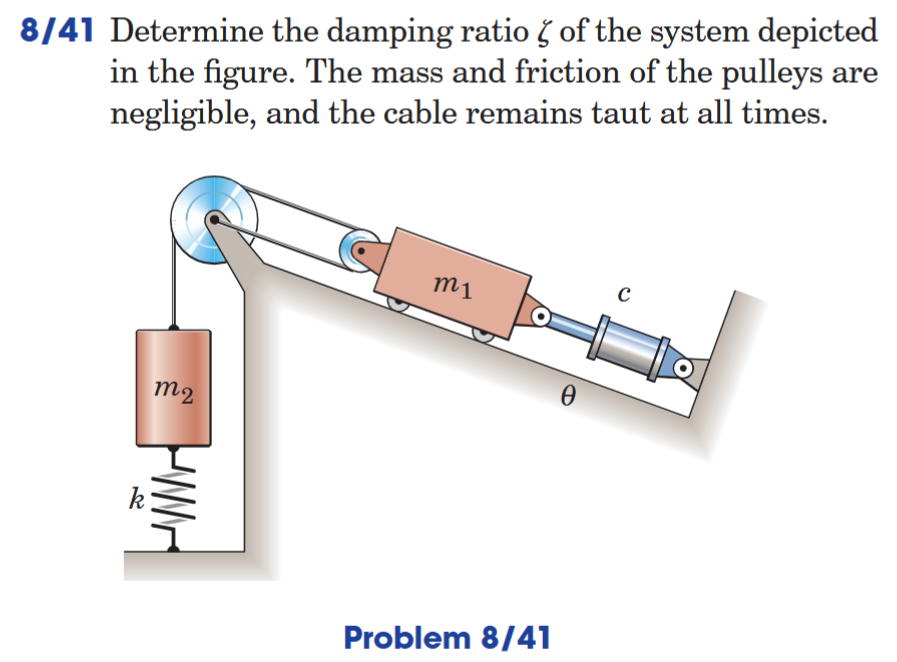
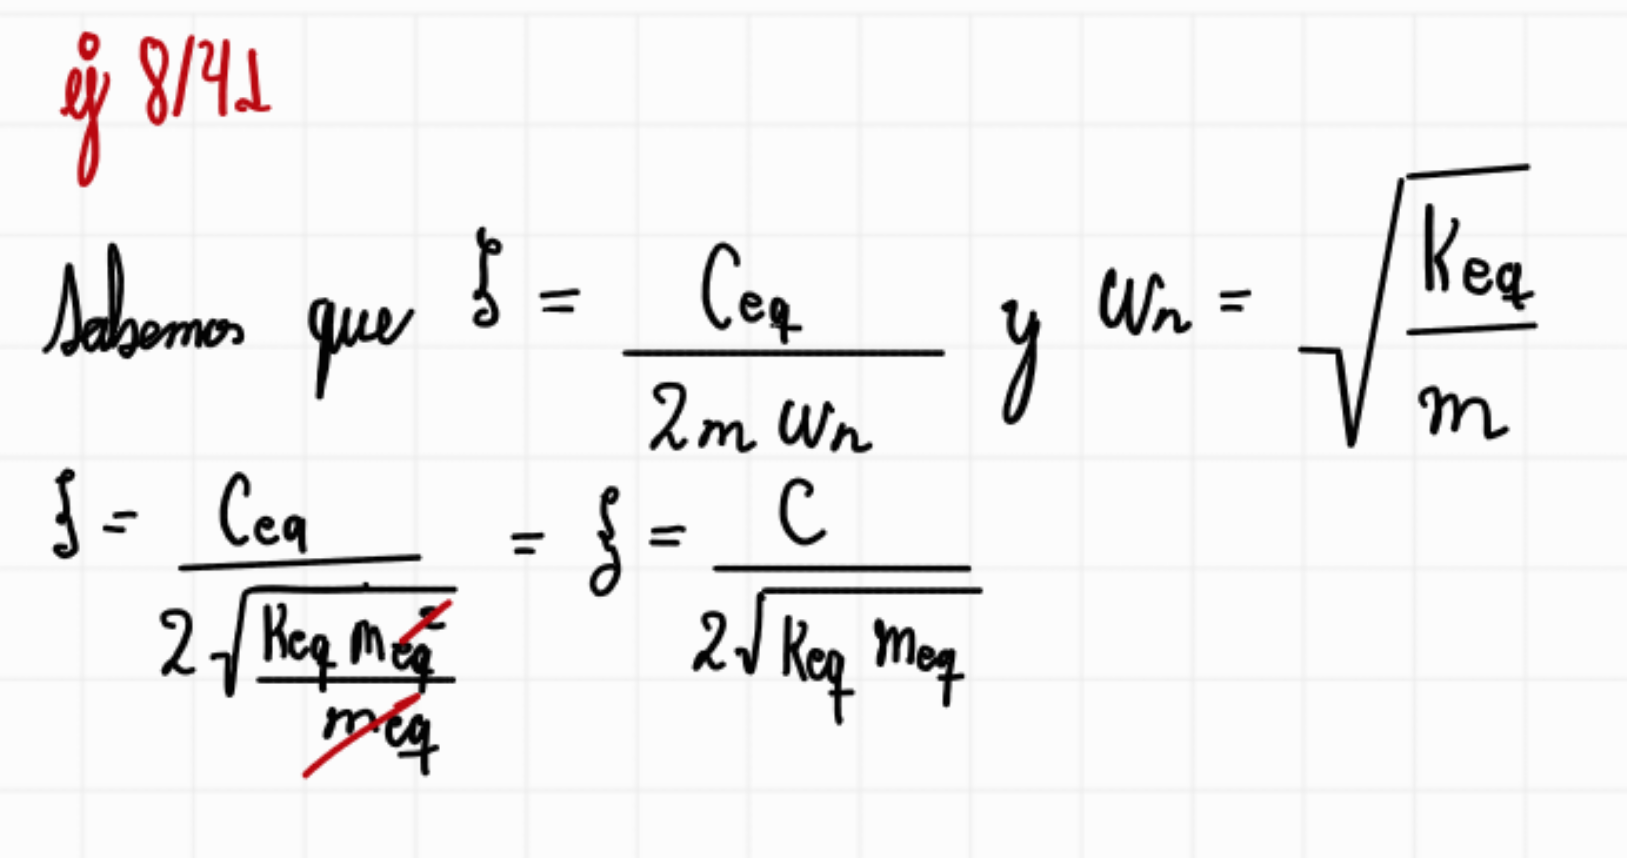
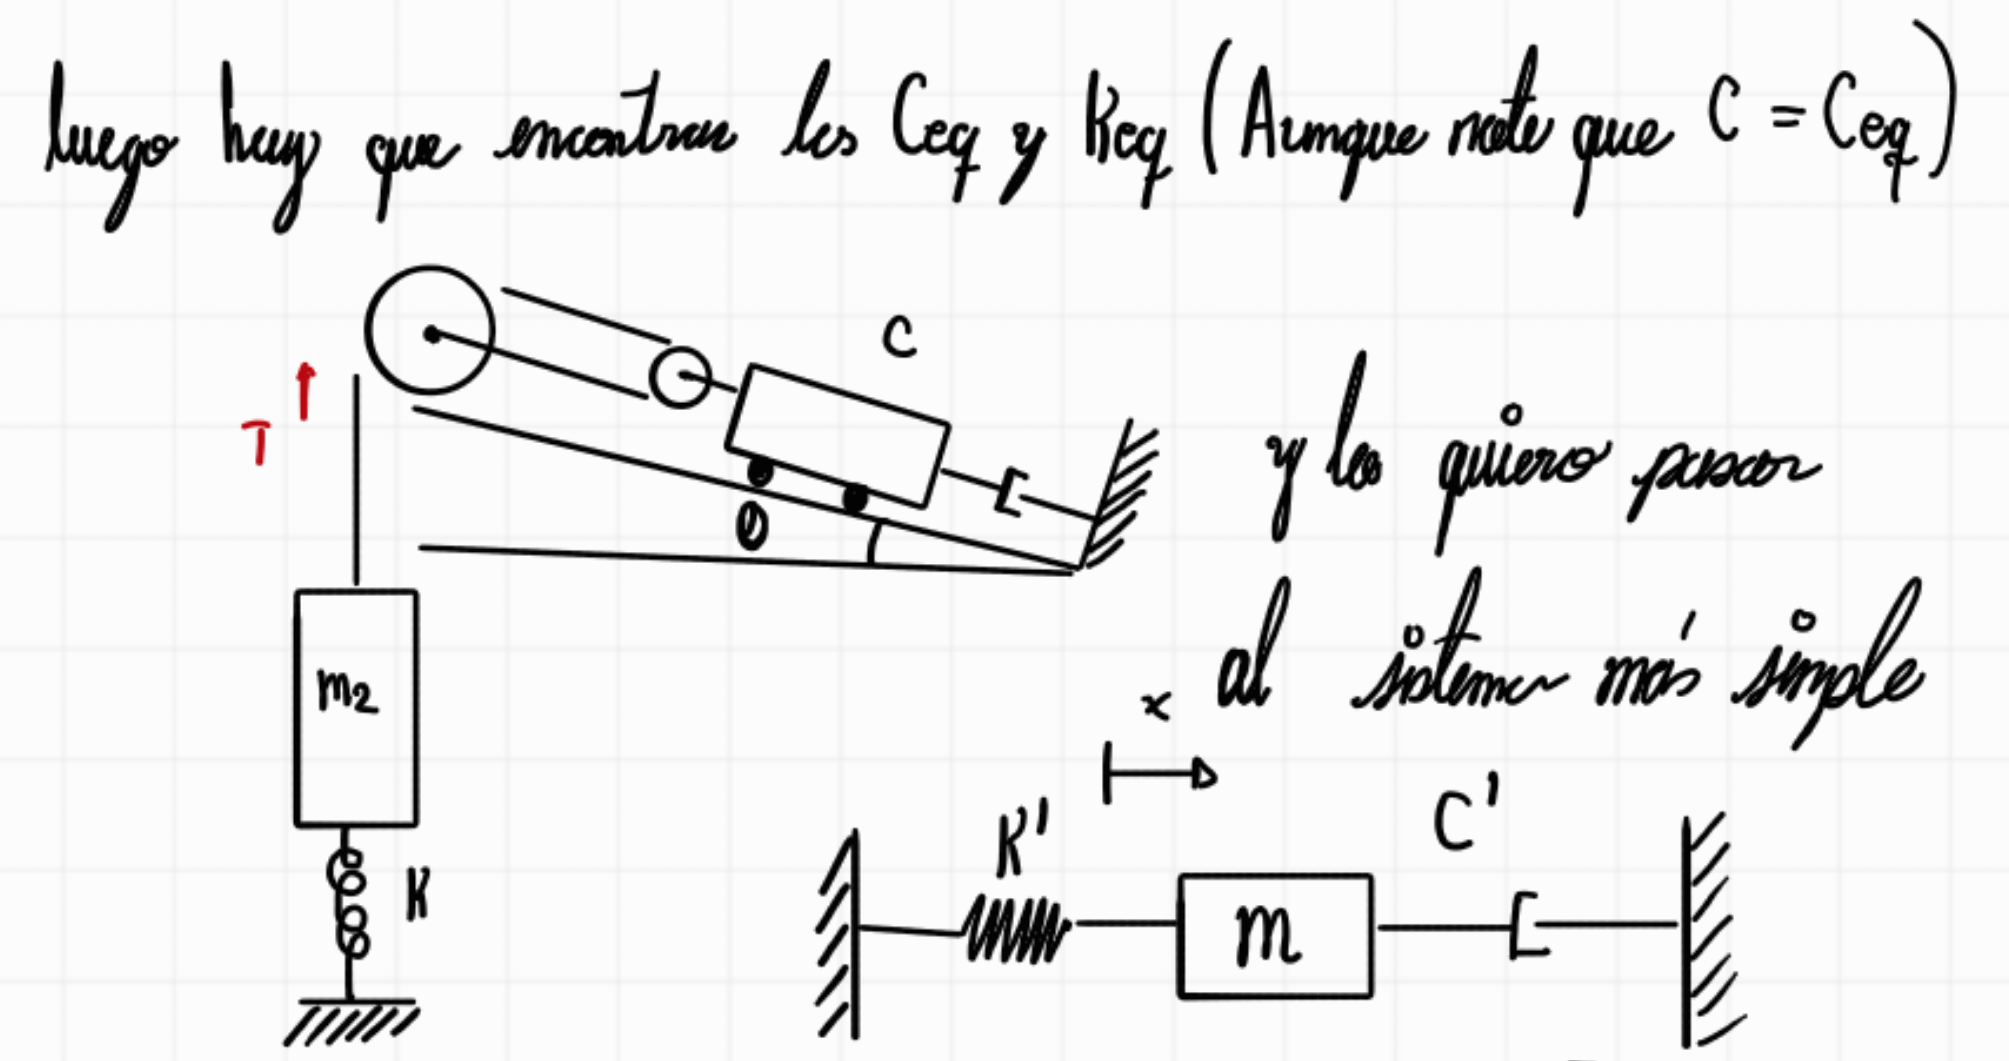
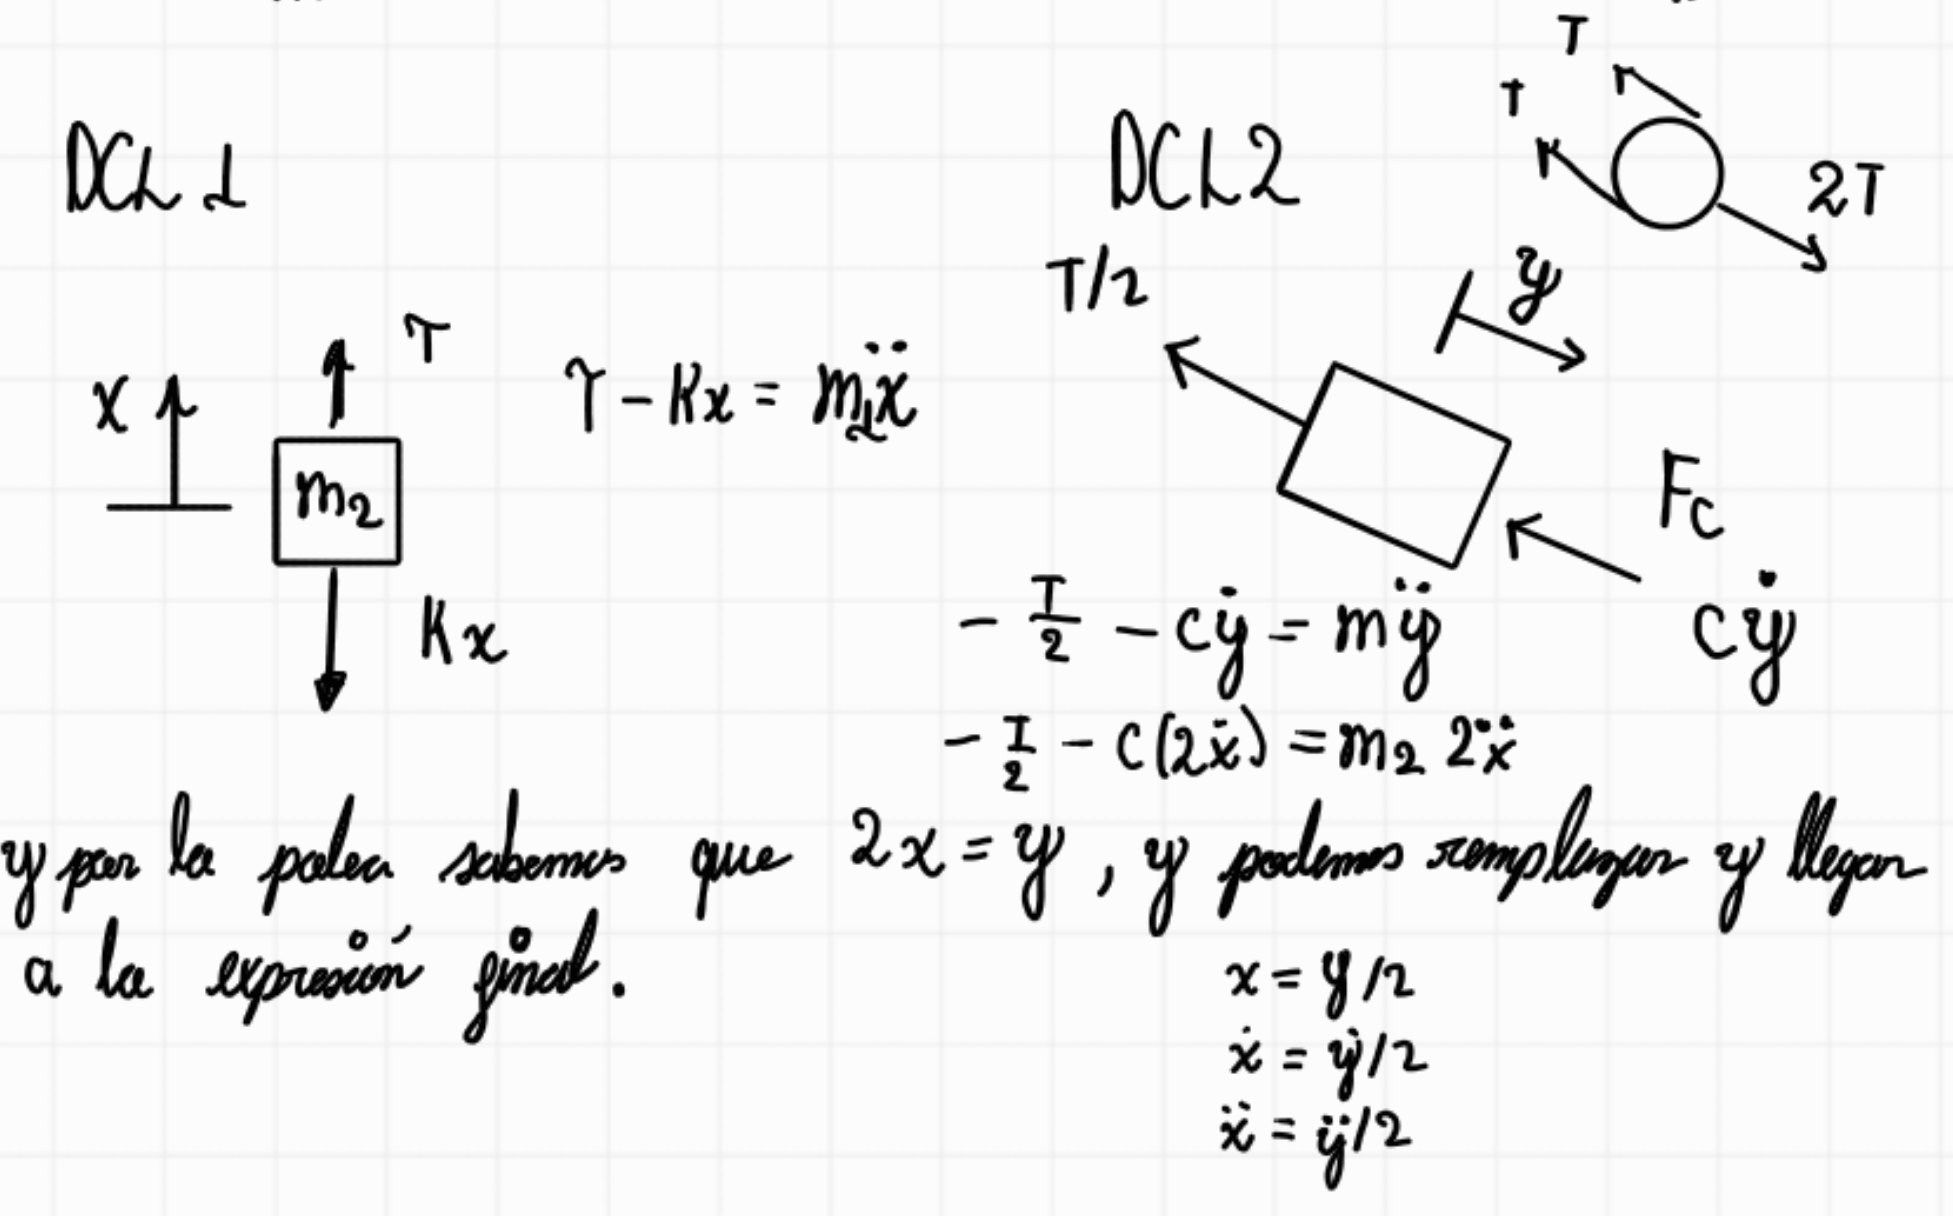
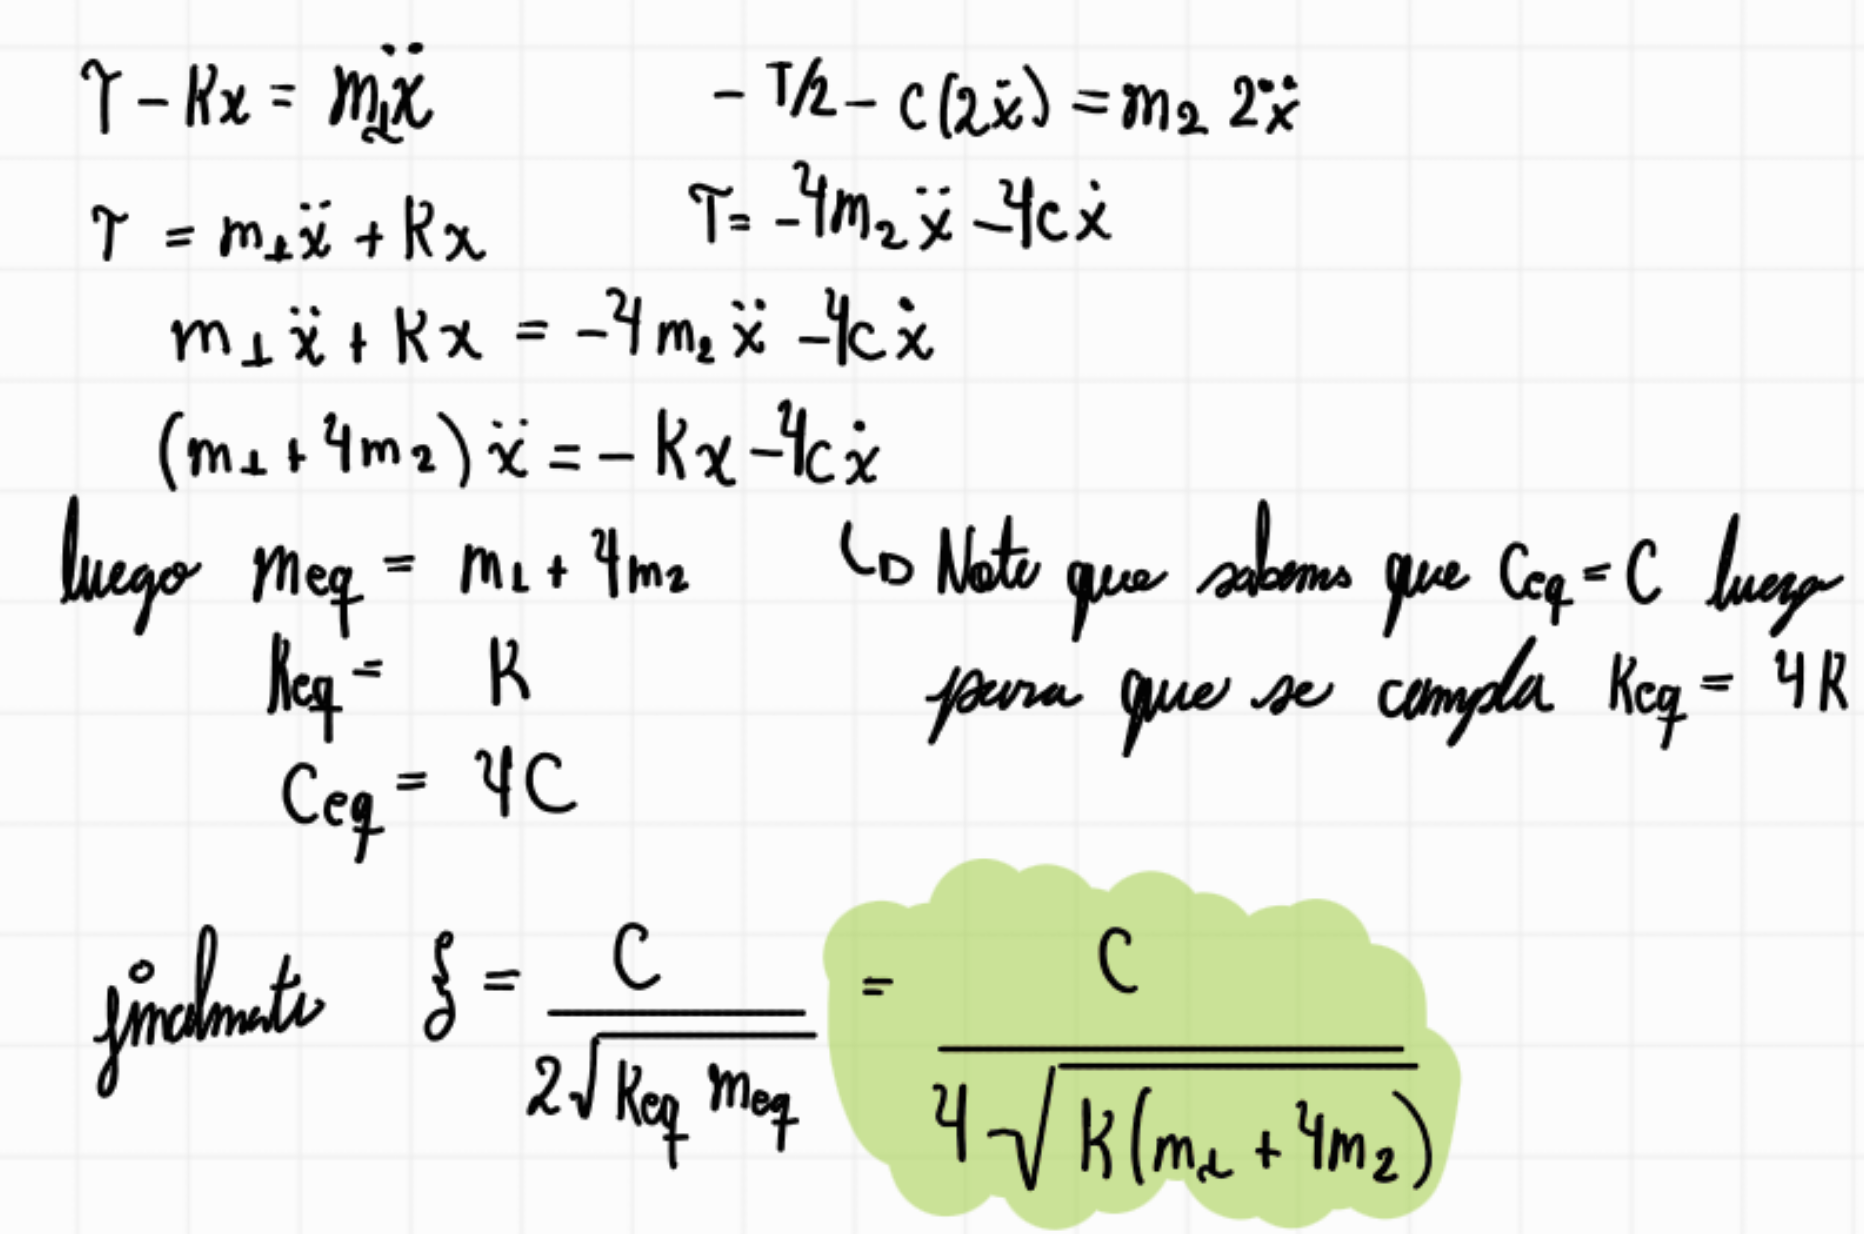

In [15]:
# A mano hice el sistema  por cinemática y N-E pero computacionalmente es mucho más facil hacerlo por energías
# (Esto sale como dos cap más adelante del problema en el libro pero igual tiene mucho sentido hacerlo así)

m1, m2, k, c = symbols('m1 m2 k c', positive=True)
x = symbols('x', real=True)     


y = 2*x # Razón de los movimientos

x_dot = symbols('x_dot') # Vel
y_dot = 2*x_dot # Vel

T = (1/2)*m1*x_dot**2 + (1/2)*m2*y_dot**2 # Energía en la tensión de la polea
T_simplified = simplify(T)


m_eq = simplify( diff(diff(T_simplified, x_dot), x_dot) ) # Despejamos de la energía la relación entre masas


V = (1/2)*k*(2*x)**2 # Podemos despejar la relación entre velocidades
k_eq = simplify(diff(diff(V, x), x)) # Derivamos 


c_eq = c # Como hice a mano y como lo hago haca el sistema equivalente solo tiene sentido si asumimos el c igual

zeta = simplify( c_eq / (2*sqrt(k_eq*m_eq)) ) # Sustituimos en zeta

display("m_eq =", m_eq)
display("k_eq =", k_eq)
display("c_eq =", c_eq)
display("zeta =", zeta)


'm_eq ='

1.0⋅m₁ + 4.0⋅m₂

'k_eq ='

4.0⋅k

'c_eq ='

c

'zeta ='

        0.25⋅c        
──────────────────────
     _________________
√k⋅╲╱ 1.0⋅m₁ + 4.0⋅m₂ 